# 05 Predictive Intelligence

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
DB_PATH = '../data/reviews_analysis.db'

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

PyTorch version: 2.10.0+cu128
Device: CUDA


In [2]:
conn = sqlite3.connect(DB_PATH)
reviews = pd.read_sql('SELECT * FROM reviews', conn)
authors = pd.read_sql('SELECT id, num_cities, num_helpful_votes, num_reviews FROM authors', conn)
conn.close()

reviews['review_date'] = pd.to_datetime(reviews['review_date'], errors='coerce')
print(f'Reviews loaded: {len(reviews):,}')
print(f'Columns: {list(reviews.columns)}')
reviews.head(3)

Reviews loaded: 80,000
Columns: ['title', 'text', 'date_stayed', 'hotel_id', 'num_helpful_votes', 'review_date', 'review_id', 'via_mobile', 'service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating', 'author_id']


,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01 00:00:00,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01 00:00:00,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01 00:00:00,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75


---
## Problem 1: Predict Overall Rating from Aspect Ratings


**Features:** `service`, `cleanliness`, `value`, `location`, `sleep_quality`, `rooms` ratings  
**Target:** `overall_rating` (1–5 scale)

Samples after dropping NaN: 58,190 (from 80,000)

Target distribution:
overall_rating
1.0     2646
2.0     3339
3.0     8231
4.0    19329
5.0    24645
Name: count, dtype: int64


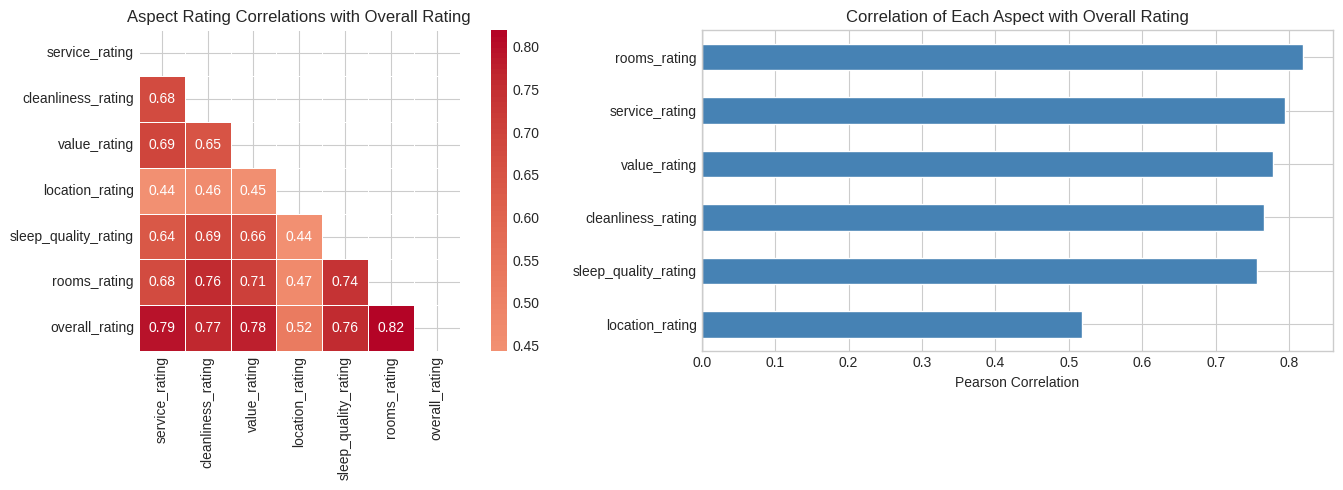

In [3]:
# Data preparation
ASPECT_COLS = ['service_rating', 'cleanliness_rating', 'value_rating',
               'location_rating', 'sleep_quality_rating', 'rooms_rating']
TARGET_1A = 'overall_rating'

df_1a = reviews[ASPECT_COLS + [TARGET_1A]].dropna()
print(f'Samples after dropping NaN: {len(df_1a):,} (from {len(reviews):,})')
print(f'\nTarget distribution:\n{df_1a[TARGET_1A].value_counts().sort_index()}')

# EDA: Correlations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr = df_1a.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[0], cmap='coolwarm',
            center=0, square=True, mask=mask, linewidths=0.5)
axes[0].set_title('Aspect Rating Correlations with Overall Rating', fontsize=12)

corr[TARGET_1A].drop(TARGET_1A).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Correlation of Each Aspect with Overall Rating', fontsize=12)
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

In [ ]:
# Train/test split
X_1a = df_1a[ASPECT_COLS].values
y_1a = df_1a[TARGET_1A].values

X_train, X_test, y_train, y_test = train_test_split(
    X_1a, y_1a, test_size=0.2, random_state=RANDOM_STATE
)

scaler_1a = StandardScaler()
X_train_s = scaler_1a.fit_transform(X_train)
X_test_s  = scaler_1a.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')


def eval_reg(y_true, y_pred, name):
    return {
        'Model': name,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R2':   round(r2_score(y_true, y_pred), 4)
    }


results_1a = []

Train: 46,552 | Test: 11,638


In [5]:
# Sklearn models
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
results_1a.append(eval_reg(y_test, lr.predict(X_test_s), 'Linear Regression'))

# Ridge Regression
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_s, y_train)
results_1a.append(eval_reg(y_test, ridge.predict(X_test_s), 'Ridge Regression'))

# Random Forest (no scaling needed for tree models)
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
results_1a.append(eval_reg(y_test, rf_reg.predict(X_test), 'Random Forest'))

# Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                    max_depth=4, random_state=RANDOM_STATE)
gb_reg.fit(X_train, y_train)
results_1a.append(eval_reg(y_test, gb_reg.predict(X_test), 'Gradient Boosting'))

print('Sklearn models trained.')
for r in results_1a:
    print(f"  {r['Model']:<22} MAE={r['MAE']:.4f}  RMSE={r['RMSE']:.4f}  R2={r['R2']:.4f}")

Sklearn models trained.
  Linear Regression      MAE=0.3277  RMSE=0.4614  R2=0.8196
  Ridge Regression       MAE=0.3277  RMSE=0.4614  R2=0.8196
  Random Forest          MAE=0.3154  RMSE=0.4521  R2=0.8268
  Gradient Boosting      MAE=0.3171  RMSE=0.4479  R2=0.8300


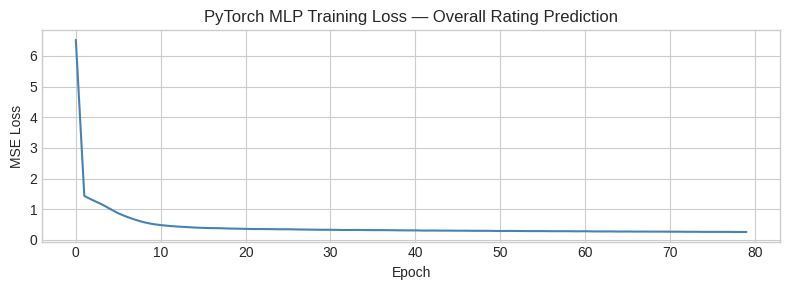

Final train loss: 0.2610


In [ ]:
# PyTorch MLP
class RatingMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_tr_t = torch.FloatTensor(X_train_s).to(DEVICE)
y_tr_t = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_te_t = torch.FloatTensor(X_test_s).to(DEVICE)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=512, shuffle=True)

model_1a = RatingMLP(X_train_s.shape[1]).to(DEVICE)
optimizer_1a = optim.Adam(model_1a.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_reg = nn.MSELoss()
scheduler_1a = optim.lr_scheduler.ReduceLROnPlateau(optimizer_1a, patience=5, factor=0.5)

train_losses_1a = []
N_EPOCHS = 80

for epoch in range(N_EPOCHS):
    model_1a.train()
    epoch_loss = 0.0
    for bx, by in train_dl:
        optimizer_1a.zero_grad()
        loss = criterion_reg(model_1a(bx), by)
        loss.backward()
        optimizer_1a.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_dl)
    train_losses_1a.append(avg)
    scheduler_1a.step(avg)

model_1a.eval()
with torch.no_grad():
    y_pred_mlp_1a = model_1a(X_te_t).cpu().numpy().flatten()

results_1a.append(eval_reg(y_test, y_pred_mlp_1a, 'PyTorch MLP'))

# Training loss plot
plt.figure(figsize=(8, 3))
plt.plot(train_losses_1a, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('PyTorch MLP Training Loss: Overall Rating Prediction')
plt.tight_layout()
plt.show()
print(f'Final train loss: {train_losses_1a[-1]:.4f}')

=== Problem 1: Overall Rating Prediction: Model Comparison ===
               Model     MAE    RMSE      R2
1  Gradient Boosting  0.3171  0.4479  0.8300
2      Random Forest  0.3154  0.4521  0.8268
3        PyTorch MLP  0.3223  0.4522  0.8267
4  Linear Regression  0.3277  0.4614  0.8196
5   Ridge Regression  0.3277  0.4614  0.8196


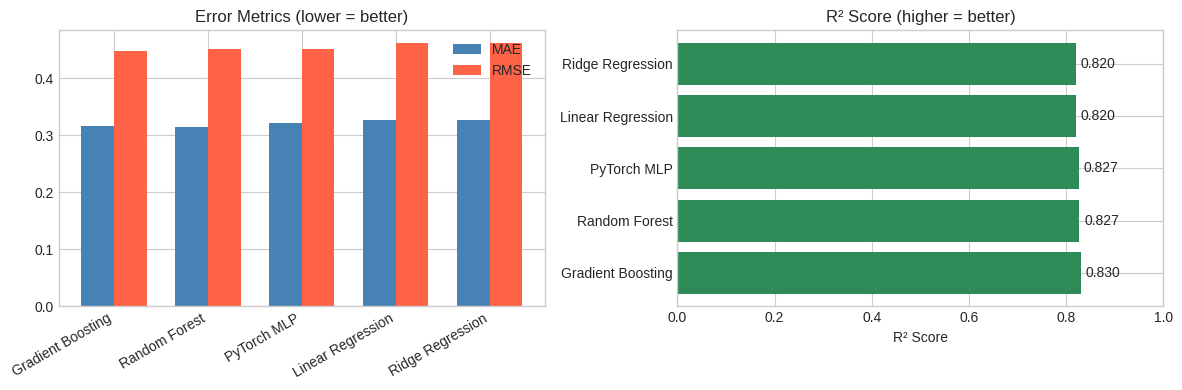

In [ ]:
# Results comparison
res_1a_df = pd.DataFrame(results_1a).sort_values('RMSE').reset_index(drop=True)
res_1a_df.index += 1
print('=== Problem 1: Overall Rating Prediction: Model Comparison ===')
print(res_1a_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Model comparison bar chart
x = np.arange(len(res_1a_df))
w = 0.35
axes[0].bar(x - w/2, res_1a_df['MAE'], w, label='MAE', color='steelblue')
axes[0].bar(x + w/2, res_1a_df['RMSE'], w, label='RMSE', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(res_1a_df['Model'], rotation=30, ha='right')
axes[0].set_title('Error Metrics (lower = better)')
axes[0].legend()

# R² comparison
axes[1].barh(res_1a_df['Model'], res_1a_df['R2'], color='seagreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² Score (higher = better)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(res_1a_df['R2']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


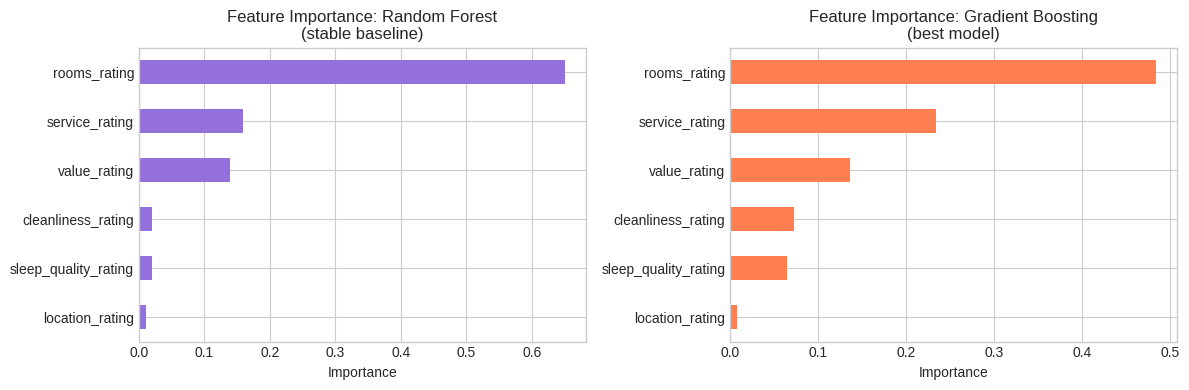

Feature importance comparison:
                      Random Forest  Gradient Boosting
rooms_rating               0.650532           0.484237
service_rating             0.158857           0.233764
value_rating               0.139556           0.136611
cleanliness_rating         0.020676           0.072967
sleep_quality_rating       0.019840           0.064487
location_rating            0.010539           0.007933

Most influential aspect (RF): rooms_rating (importance=0.651)
Most influential aspect (GB): rooms_rating (importance=0.484)

Recommended model: Gradient Boosting  (RMSE=0.4479, R²=0.8300)


In [ ]:
# Feature importance comparison
feat_imp_rf = pd.Series(rf_reg.feature_importances_, index=ASPECT_COLS).sort_values()
feat_imp_gb = pd.Series(gb_reg.feature_importances_, index=ASPECT_COLS).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

feat_imp_rf.plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Feature Importance: Random Forest\n(stable baseline)')
axes[0].set_xlabel('Importance')

feat_imp_gb.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Importance: Gradient Boosting\n(best model)')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

cmp = pd.DataFrame({'Random Forest': feat_imp_rf, 'Gradient Boosting': feat_imp_gb}).sort_values('Random Forest', ascending=False)
print('Feature importance comparison:')
print(cmp.to_string())
print(f'\nMost influential aspect (RF): {feat_imp_rf.idxmax()} (importance={feat_imp_rf.max():.3f})')
print(f'Most influential aspect (GB): {feat_imp_gb.idxmax()} (importance={feat_imp_gb.max():.3f})')

best_1a = res_1a_df.iloc[0]
print(f'\nRecommended model: {best_1a["Model"]}  (RMSE={best_1a["RMSE"]:.4f}, R²={best_1a["R2"]:.4f})')


### Problem 1: Overall Rating Prediction
- **Rooms rating has the strongest influence** on overall rating.
